## About the CIFAR 10 Dataset:
The CIFAR-10 dataset is a widely used dataset in the field of machine learning and computer vision. It consists of 60,000 color images of size 32x32 pixels, categorized into 10 different classes. Each class contains 6,000 images, making it a balanced dataset.

Classes and Structure

The 10 classes in the CIFAR-10 dataset are:

Airplane

Automobile

Bird

Cat

Deer

Dog

Frog

Horse

Ship

Truck

The dataset is divided into 50,000 training images and 10,000 test images. This division allows researchers to train their models on a substantial amount of data and then evaluate their performance on a separate set of images.

## 1.Import Libraries

In [1]:
import pandas as pd
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Flatten,Dense,Dropout
import numpy as np
import matplotlib.pyplot as plt

## 2.Import Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
assert x_train.shape == (50000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1924s 11us/step


## 3.Data Understanding

In [4]:
print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


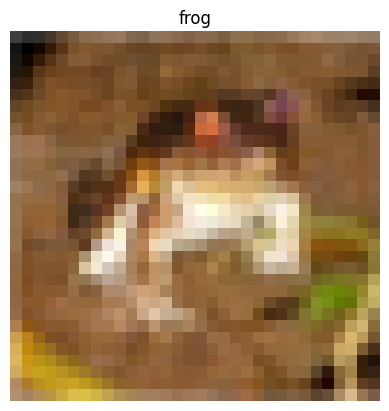

In [5]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

plt.imshow(x_train[0])
plt.title(class_names[y_train[0][0]])
plt.axis("off")
plt.show()

## 4.Data Preparation

In [6]:
# Normalizing the images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

## 5.Model Building

In [8]:
model = Sequential()
model.add(Flatten(input_shape=(32,32,3)))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(256, activation='relu'))

model.add(Dense(10, activation='softmax'))

C:\Users\sujin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │       3,146,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

##  6.Model Training | 7.Model Testing | 8.Model Evaluation

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.2537 - loss: 2.0220 - val_accuracy: 0.3315 - val_loss: 1.8608
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.3060 - loss: 1.8864 - val_accuracy: 0.3759 - val_loss: 1.7719
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.3271 - loss: 1.8339 - val_accuracy: 0.3577 - val_loss: 1.7715
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.3448 - loss: 1.7892 - val_accuracy: 0.3988 - val_loss: 1.7428
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.3570 - loss: 1.7647 - val_accuracy: 0.3845 - val_loss: 1.7263
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.3609 - loss: 1.7547 - val_accuracy: 0.4144 - val_loss: 1.6677
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.3673 - loss: 1.7349 - val_accuracy: 0.4102 - val_loss: 1.6769
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.3758 - loss: 1.7183 - 

In [12]:
#Evaluating the Model
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4489 - loss: 1.5577
Test Loss: 1.557724952697754
Test Accuracy: 0.4489000141620636


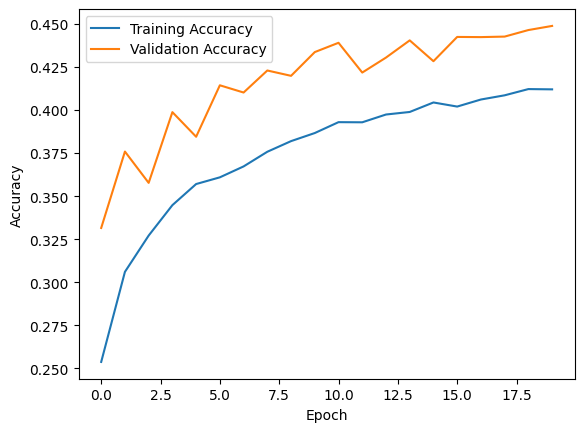

In [13]:
#Plotting Training Curves
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [14]:
prediction = model.predict(x_test[0:1])

predicted_class = np.argmax(prediction)

print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[y_test[0][0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Predicted: dog
Actual: cat


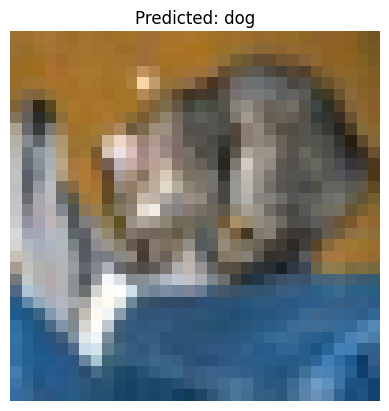

In [15]:
#Display the image
plt.imshow(x_test[0])
plt.title(f"Predicted: {class_names[predicted_class]}")
plt.axis("off")
plt.show()

In [16]:
#Save the model
model.save("cifar10_dense_model.h5")

In [17]:
# Load the Model 
from tensorflow.keras.models import load_model

model = load_model("cifar10_dense_model.h5")